# XRD Baseline & Noise Quality Analysis
**Sample:** GV008 – GSO Wide Scan  
**Instrument:** PANalytical XPERT-3 | Cu Kα | 15–55° 2θ  

This notebook characterizes the noise floor, baseline behavior, and signal quality of an XRD pattern from a sub-100 nm thin film. Rather than fitting peaks, the focus here is on **data quality metrics** — how clean is the measurement, how reliable are the detected peaks, and where does the instrument noise depart from the theoretical Poisson expectation.

Key analyses:
1. Raw data loading and overview
2. Noise floor characterization by angular region
3. Poisson noise model validation
4. Baseline estimation and residual analysis
5. SNR per detected peak
6. Data quality summary scorecard

## 1. Imports & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.stats import poisson, norm, chi2
import warnings
warnings.filterwarnings('ignore')

# ── Plotting style ──────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

In [2]:
# ── Load PANalytical CSV (header + scan points) ─────────────────
file_path = "GV008_GSO_Wide.csv"
metadata, scan_rows = {}, []
in_scan = False

with open(file_path) as f:
    for line in f:
        line = line.strip()
        if line.startswith("[Scan points]"):
            in_scan = True; continue
        if not in_scan:
            if not line.startswith("[") and "," in line:
                k, v = line.split(",", 1)
                metadata[k.strip()] = v.strip()
        else:
            if line.startswith("Angle") or not line: continue
            a, i = line.split(",")
            scan_rows.append([float(a), float(i)])

two_theta = np.array([r[0] for r in scan_rows])
intensity  = np.array([r[1] for r in scan_rows])

# Key instrument parameters from metadata
anode      = metadata.get("Anode material", "Cu")
ka1        = float(metadata.get("K-Alpha1 wavelength", 1.5406))
step_size  = float(metadata.get("Scan step size", 0.01))
time_step  = float(metadata.get("Time per step", 0.44))

print(f"Loaded {len(two_theta)} points | 2θ: {two_theta[0]:.2f}° – {two_theta[-1]:.2f}°")
print(f"Anode: {anode} | Kα1: {ka1} Å | Step: {step_size}° | Count time: {time_step} s/step")
print(f"Intensity range: {intensity.min():.0f} – {intensity.max():.0f} counts")

Loaded 4000 points | 2θ: 15.01° – 54.99°
Anode: Cu | Kα1: 1.540598 Å | Step: 0.01° | Count time: 0.44 s/step
Intensity range: 3 – 1414356 counts


## 2. Raw Pattern Overview

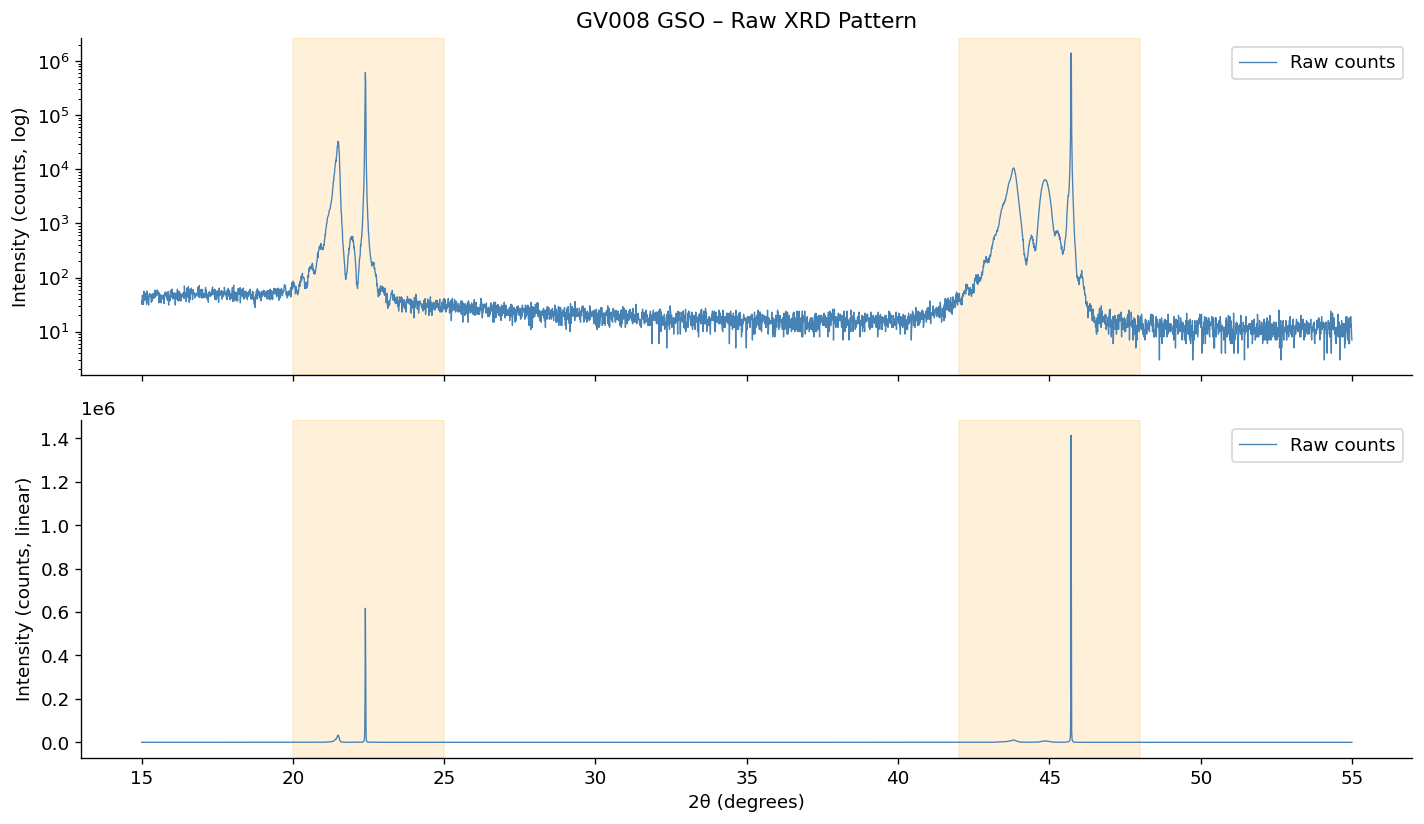

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].semilogy(two_theta, intensity, color='steelblue', linewidth=0.8, label='Raw counts')
axes[0].set_ylabel('Intensity (counts, log)')
axes[0].set_title('GV008 GSO – Raw XRD Pattern')
axes[0].legend()

axes[1].plot(two_theta, intensity, color='steelblue', linewidth=0.8, label='Raw counts')
axes[1].set_ylabel('Intensity (counts, linear)')
axes[1].set_xlabel('2θ (degrees)')
axes[1].legend()

# Shade peak mask regions
peak_mask_regions = [(20, 25), (42, 48)]
for ax in axes:
    for lo, hi in peak_mask_regions:
        ax.axvspan(lo, hi, alpha=0.15, color='orange', label='Peak region' if lo == 20 else '')

plt.tight_layout()
plt.show()

## 3. Noise Floor Characterization by Angular Region

The peak-free (baseline) regions of the pattern serve as our noise reference. We divide these into angular sub-regions to check whether the noise floor is **uniform** across the scan or drifts with angle — a key indicator of instrument health and background fluorescence.

XRD intensity counts follow **Poisson statistics**: for a mean count rate μ, the expected standard deviation is √μ. A ratio σ_actual / √μ near 1.0 indicates clean Poisson-limited noise. Values significantly above 1.0 suggest additional noise sources (electronics, sample fluorescence, vibration).

In [4]:
# Build global peak mask (True = baseline, False = peak region)
peak_mask_regions = [(20, 25), (42, 48)]
is_baseline = np.ones(len(two_theta), dtype=bool)
for lo, hi in peak_mask_regions:
    is_baseline &= ~((two_theta >= lo) & (two_theta <= hi))

# Define analysis sub-regions (all baseline)
noise_regions = [
    ("15–20°", 15, 20),
    ("25–32°", 25, 32),
    ("32–42°", 32, 42),
    ("48–55°", 48, 55),
]

records = []
for label, lo, hi in noise_regions:
    seg_mask = (two_theta >= lo) & (two_theta <= hi) & is_baseline
    seg = intensity[seg_mask]
    mu    = seg.mean()
    sigma = seg.std()
    poisson_sigma = np.sqrt(mu)
    ratio = sigma / poisson_sigma if poisson_sigma > 0 else np.nan
    records.append({
        "Region": label,
        "N points": int(seg_mask.sum()),
        "Mean (counts)": round(mu, 1),
        "Std Dev": round(sigma, 2),
        "√Mean (Poisson)": round(poisson_sigma, 2),
        "σ / √μ ratio": round(ratio, 3),
        "Poisson-limited?": "✓" if ratio < 1.5 else "✗ excess noise",
    })

noise_df = pd.DataFrame(records)
print(noise_df.to_string(index=False))

Region  N points  Mean (counts)  Std Dev  √Mean (Poisson)  σ / √μ ratio Poisson-limited?
15–20°       500           49.3     7.98             7.02         1.136                ✓
25–32°       700           22.7     5.73             4.76         1.204                ✓
32–42°      1000           17.6     6.04             4.19         1.441                ✓
48–55°       700           11.9     3.59             3.44         1.044                ✓


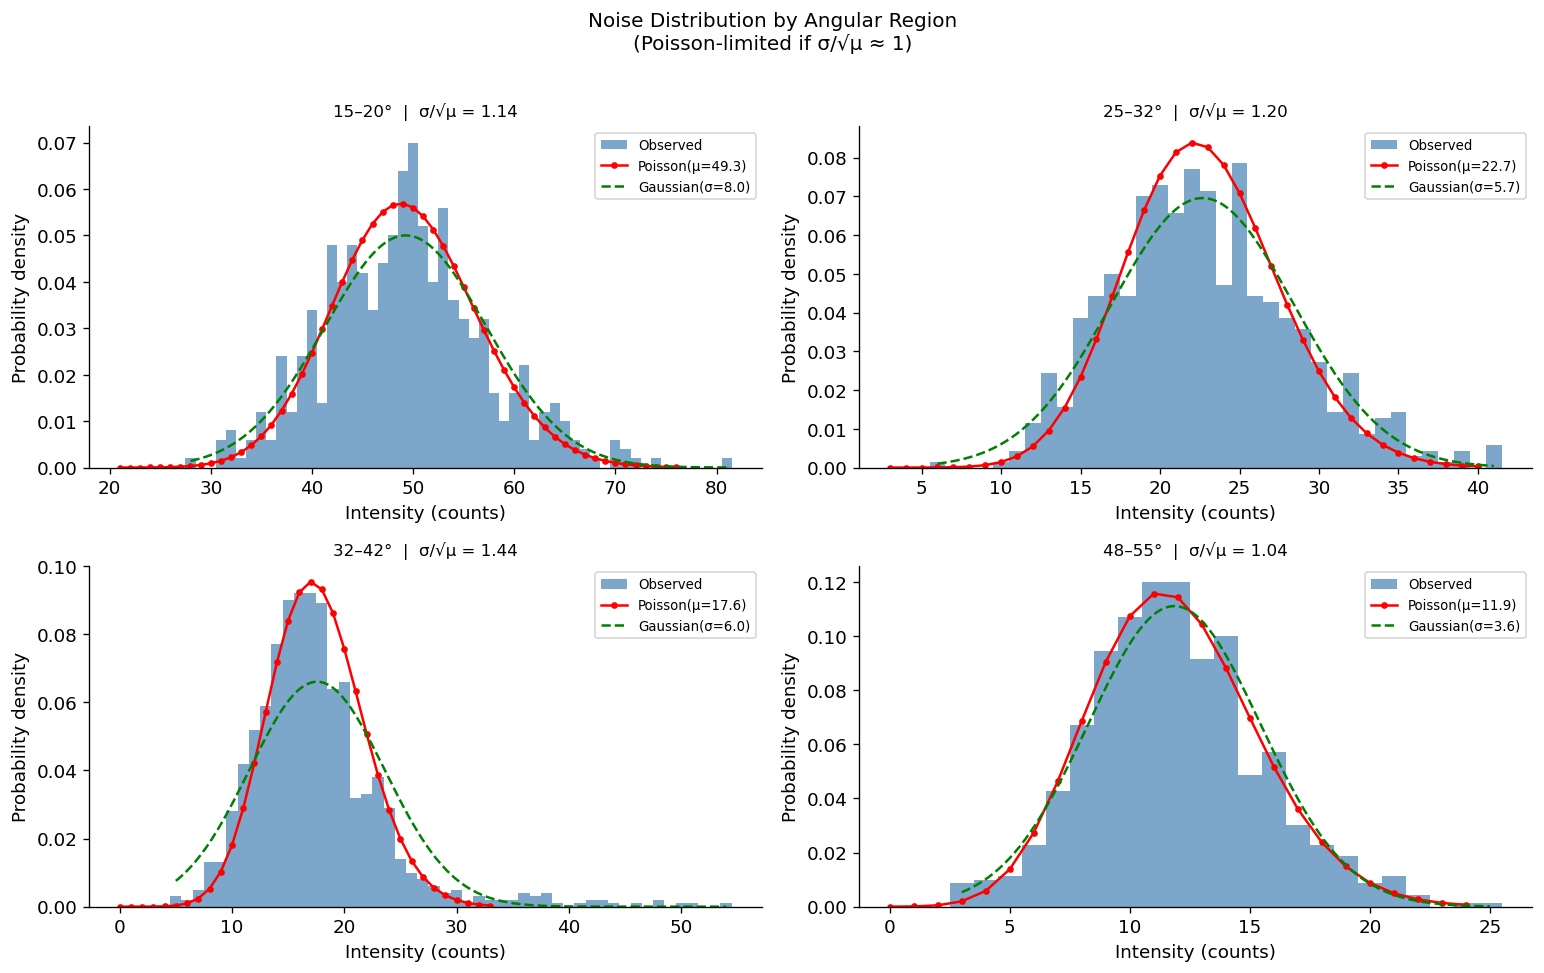

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for ax, (label, lo, hi) in zip(axes, noise_regions):
    seg_mask = (two_theta >= lo) & (two_theta <= hi) & is_baseline
    seg = intensity[seg_mask]
    mu, sigma = seg.mean(), seg.std()
    poisson_sigma = np.sqrt(mu)

    # Histogram of counts in region
    bins = np.arange(seg.min(), seg.max() + 2) - 0.5
    ax.hist(seg, bins=bins, color='steelblue', alpha=0.7, density=True, label='Observed')

    # Overlay Poisson PMF
    k_range = np.arange(max(0, int(mu - 4*poisson_sigma)), int(mu + 4*poisson_sigma))
    poisson_pmf = poisson.pmf(k_range, mu)
    ax.plot(k_range, poisson_pmf, 'r-o', markersize=3, linewidth=1.5, label=f'Poisson(μ={mu:.1f})')

    # Overlay Gaussian for reference
    x_range = np.linspace(seg.min(), seg.max(), 200)
    gauss_pdf = norm.pdf(x_range, mu, sigma)
    ax.plot(x_range, gauss_pdf, 'g--', linewidth=1.5, label=f'Gaussian(σ={sigma:.1f})')

    ratio = sigma / poisson_sigma
    ax.set_title(f"{label}  |  σ/√μ = {ratio:.2f}", fontsize=10)
    ax.set_xlabel('Intensity (counts)')
    ax.set_ylabel('Probability density')
    ax.legend(fontsize=8)

plt.suptitle('Noise Distribution by Angular Region\n(Poisson-limited if σ/√μ ≈ 1)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 4. Baseline Estimation & Residual Analysis

We compare two background subtraction methods:
- **Polynomial fit (deg 3)** — fast, parametric, but can over/under-correct if the background is non-monotonic
- **SNIP approximation (iterative minimum)** — non-parametric, widely used in XRD/XRF, more robust to complex backgrounds

After subtraction, the residuals in the baseline regions should look like white noise centered at zero. Systematic structure in the residuals (oscillations, drift) indicates the baseline model is imperfect.

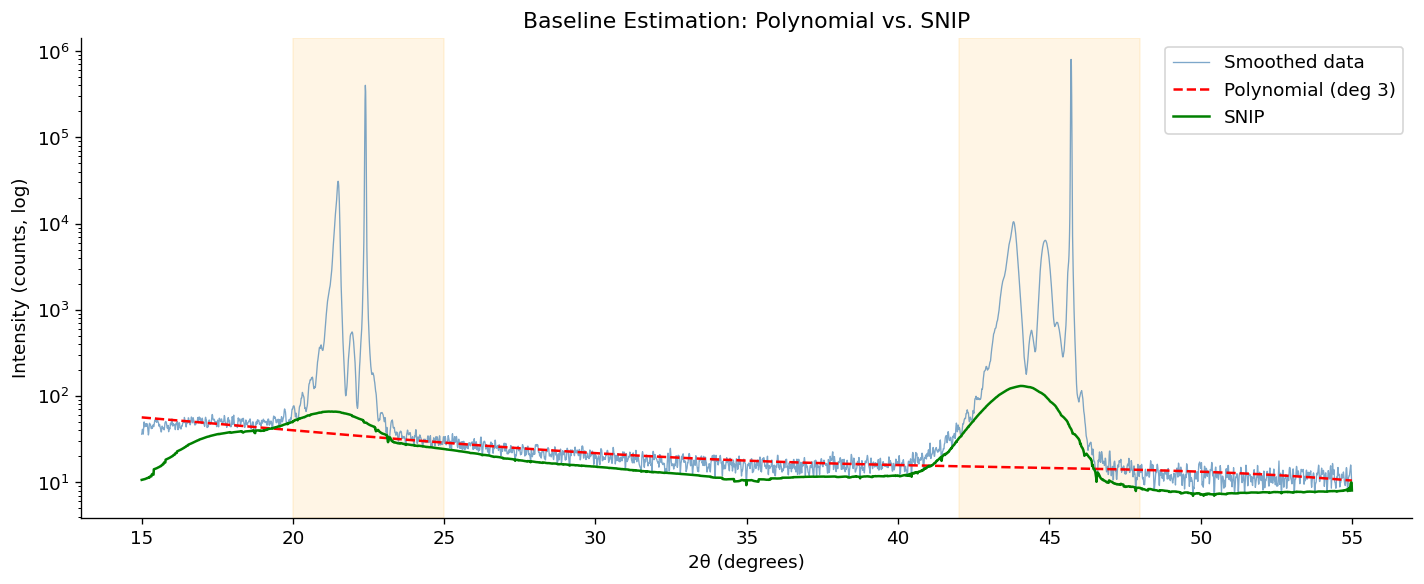

In [6]:
from scipy.ndimage import gaussian_filter1d

smoothed = gaussian_filter1d(intensity.astype(float), sigma=1)

# ── Method 1: Polynomial baseline ──────────────────────────────
coeffs   = np.polyfit(two_theta[is_baseline], smoothed[is_baseline], deg=3)
baseline_poly = np.polyval(coeffs, two_theta)

# ── Method 2: SNIP (Statistics-sensitive Non-linear Iterative Peak-clipping) ──
# Implemented manually — iterative minimum smoothing
def snip_baseline(y, n_iterations=40):
    """
    SNIP algorithm for background estimation.
    Iteratively replaces each point with the average of its neighbors
    at increasing window widths, keeping only the minimum.
    Standard in XRF/XRD background correction (Ryan et al. 1988).
    """
    import math
    v = np.log(np.log(np.sqrt(y + 1) + 1) + 1)  # variance-stabilizing transform
    v_work = v.copy()
    for p in range(1, n_iterations + 1):
        shifted_avg = (np.roll(v_work, p) + np.roll(v_work, -p)) / 2
        v_work = np.minimum(v_work, shifted_avg)
    # Invert transform
    return (np.exp(np.exp(v_work) - 1) - 1) ** 2 - 1

baseline_snip = snip_baseline(smoothed, n_iterations=40)

# ── Plot both baselines ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
ax.semilogy(two_theta, smoothed, color='steelblue', lw=0.8, alpha=0.7, label='Smoothed data')
ax.semilogy(two_theta, baseline_poly, 'r--', lw=1.5, label='Polynomial (deg 3)')
ax.semilogy(two_theta, baseline_snip, 'g-',  lw=1.5, label='SNIP')
for lo, hi in peak_mask_regions:
    ax.axvspan(lo, hi, alpha=0.1, color='orange')
ax.set_xlabel('2θ (degrees)'); ax.set_ylabel('Intensity (counts, log)')
ax.set_title('Baseline Estimation: Polynomial vs. SNIP'); ax.legend()
plt.tight_layout(); plt.show()

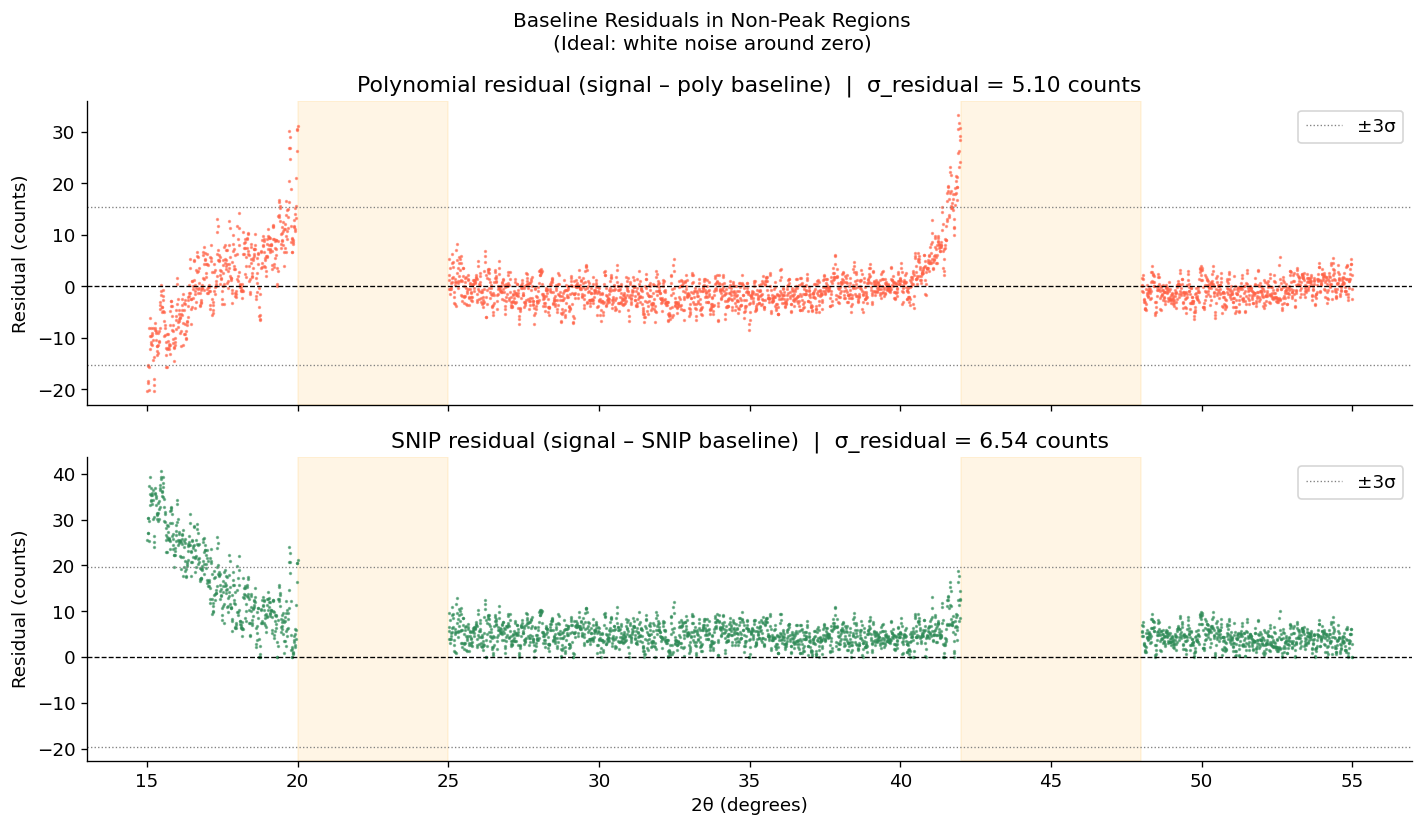

Polynomial: residual mean=-0.00, std=5.10, max|r|=33.2
SNIP: residual mean=6.96, std=6.54, max|r|=40.7


In [7]:
corrected_poly  = smoothed - baseline_poly
corrected_snip  = smoothed - baseline_snip

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

for ax, residual, label, color in zip(
    axes,
    [corrected_poly, corrected_snip],
    ['Polynomial residual (signal – poly baseline)',
     'SNIP residual (signal – SNIP baseline)'],
    ['tomato', 'seagreen']
):
    # Baseline-only residuals
    res_baseline = residual[is_baseline]
    ax.plot(two_theta[is_baseline], res_baseline, '.', color=color, ms=2, alpha=0.6)
    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.axhline( 3*res_baseline.std(), color='gray', lw=0.8, ls=':', label='±3σ')
    ax.axhline(-3*res_baseline.std(), color='gray', lw=0.8, ls=':')
    for lo, hi in peak_mask_regions:
        ax.axvspan(lo, hi, alpha=0.1, color='orange')
    ax.set_ylabel('Residual (counts)')
    ax.set_title(f"{label}  |  σ_residual = {res_baseline.std():.2f} counts")
    ax.legend()

axes[-1].set_xlabel('2θ (degrees)')
plt.suptitle('Baseline Residuals in Non-Peak Regions\n(Ideal: white noise around zero)', fontsize=12)
plt.tight_layout(); plt.show()

# Quantitative comparison
for name, residual in [('Polynomial', corrected_poly), ('SNIP', corrected_snip)]:
    r = residual[is_baseline]
    print(f"{name}: residual mean={r.mean():.2f}, std={r.std():.2f}, max|r|={np.abs(r).max():.1f}")

## 5. Signal-to-Noise Ratio per Peak

SNR is defined here as the **peak amplitude above baseline divided by the local noise standard deviation**, computed in a window around each peak (excluding the peak center itself). 

SNR < 3 is generally considered below the detection limit in analytical spectroscopy. SNR 3–10 is marginal. SNR > 10 is reliable for quantitative work like Rietveld refinement or Scherrer analysis.

In [8]:
# Detect peaks on polynomial-corrected data
peaks_idx, _ = find_peaks(corrected_poly, prominence=400, distance=20)

snr_records = []
for p in peaks_idx:
    window = 60   # ±60 points around peak for local noise estimate
    lo = max(0, p - window)
    hi = min(len(two_theta), p + window)

    # Exclude peak center (±15 points) from noise window
    local_indices = np.arange(lo, hi)
    center_excl   = (local_indices >= p - 15) & (local_indices <= p + 15)
    noise_counts  = intensity[local_indices[~center_excl]]

    local_noise_std  = noise_counts.std()
    local_noise_mean = noise_counts.mean()
    peak_amplitude   = corrected_poly[p]
    snr = peak_amplitude / local_noise_std if local_noise_std > 0 else np.nan
    poisson_limited_snr = peak_amplitude / np.sqrt(local_noise_mean) if local_noise_mean > 0 else np.nan

    snr_records.append({
        "2θ (°)": round(two_theta[p], 3),
        "Peak amplitude": int(peak_amplitude),
        "Local noise σ": round(local_noise_std, 1),
        "Measured SNR": round(snr, 1),
        "Poisson-limit SNR": round(poisson_limited_snr, 1),
        "Quality": "✓ Reliable" if snr > 10 else ("~ Marginal" if snr > 3 else "✗ Below limit"),
    })

snr_df = pd.DataFrame(snr_records)
print(snr_df.to_string(index=False))

 2θ (°)  Peak amplitude  Local noise σ  Measured SNR  Poisson-limit SNR       Quality
 21.495           30897         1077.1          28.7             1049.1    ✓ Reliable
 21.955             518        79469.6           0.0                3.6 ✗ Below limit
 22.395          401011          155.0        2586.5            27889.7    ✓ Reliable
 43.815           10492         1267.9           8.3              276.5    ~ Marginal
 44.865            6376          659.5           9.7              224.2    ~ Marginal
 45.715          800546          275.1        2910.2            44475.6    ✓ Reliable


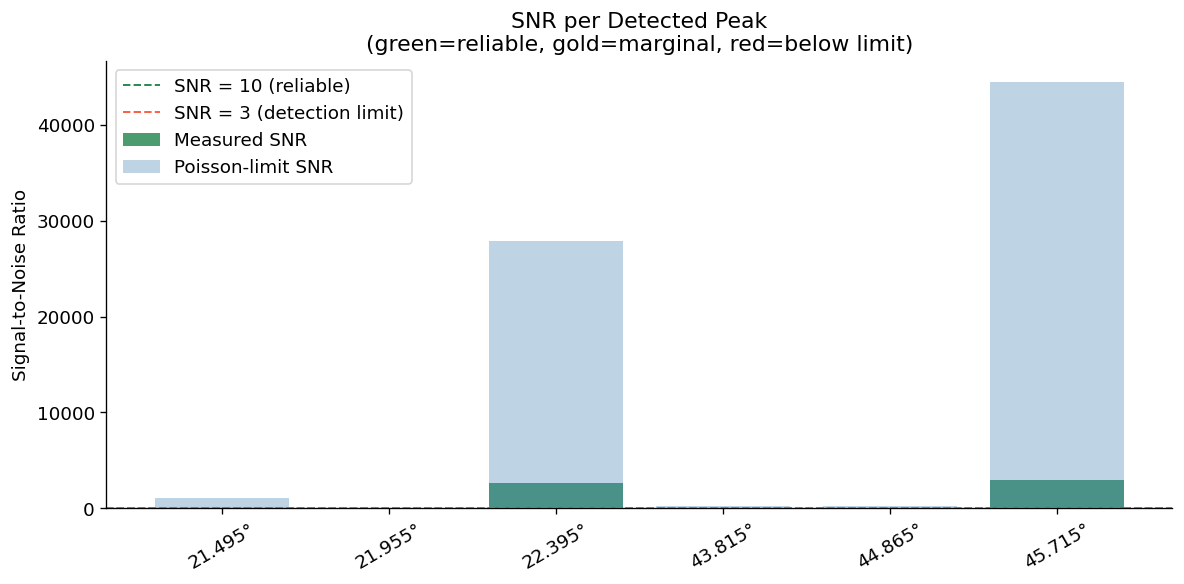

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

positions = np.arange(len(snr_df))
colors = ['seagreen' if snr > 10 else ('goldenrod' if snr > 3 else 'tomato')
          for snr in snr_df['Measured SNR']]

bars = ax.bar(positions, snr_df['Measured SNR'], color=colors, alpha=0.85, label='Measured SNR')
ax.bar(positions, snr_df['Poisson-limit SNR'], color='steelblue', alpha=0.35, label='Poisson-limit SNR')

ax.axhline(10, color='seagreen', ls='--', lw=1.2, label='SNR = 10 (reliable)')
ax.axhline(3,  color='tomato',   ls='--', lw=1.2, label='SNR = 3 (detection limit)')

ax.set_xticks(positions)
ax.set_xticklabels([f"{t}°" for t in snr_df['2θ (°)']], rotation=30)
ax.set_ylabel('Signal-to-Noise Ratio')
ax.set_title('SNR per Detected Peak\n(green=reliable, gold=marginal, red=below limit)')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Angular Dependence of Noise Floor

The noise floor should ideally decrease with angle due to decreasing background fluorescence and reduced air scatter at higher 2θ. We visualize this directly using a rolling window statistics approach on the baseline-only points.

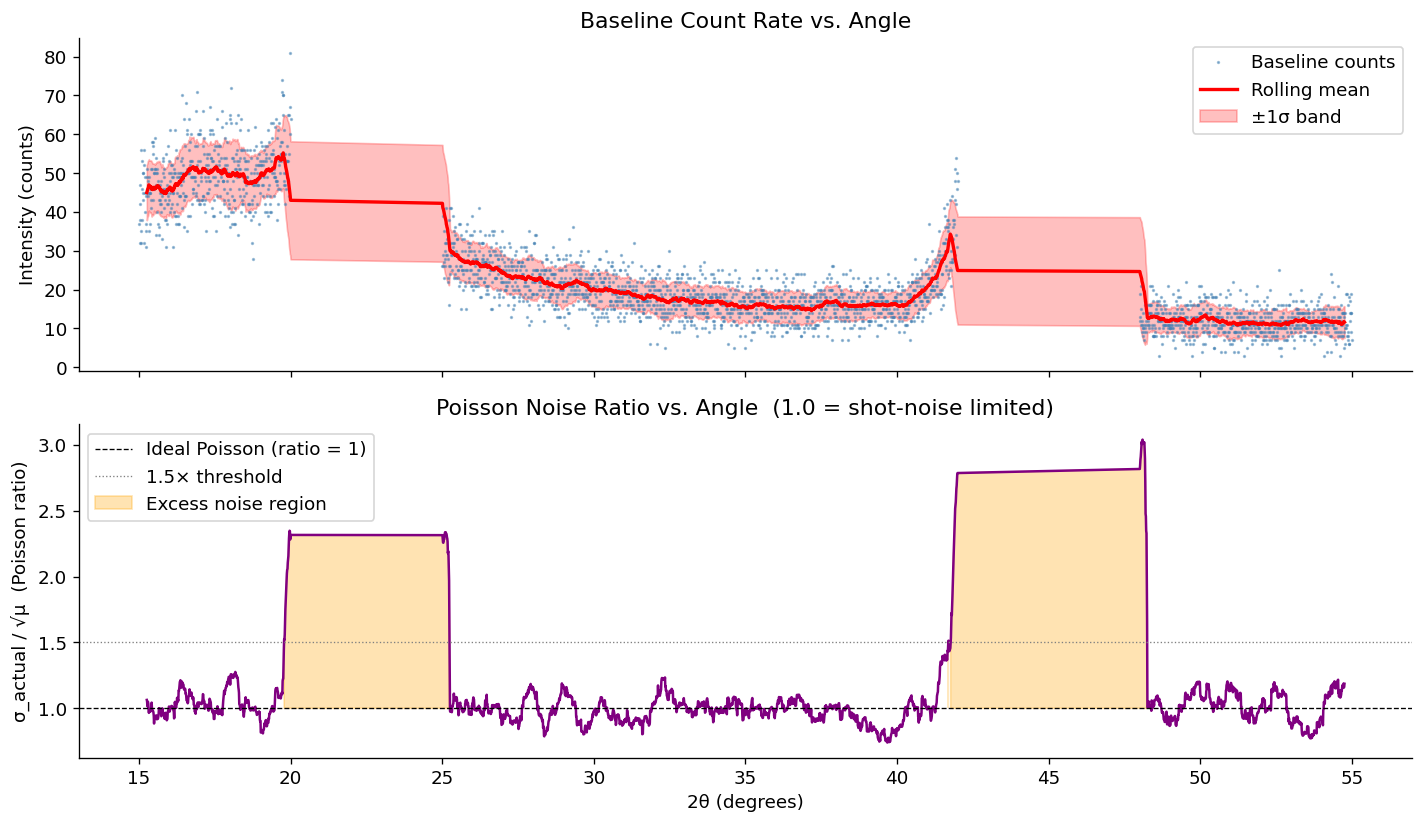

In [10]:
# Rolling statistics on baseline-only points
baseline_theta   = two_theta[is_baseline]
baseline_counts  = intensity[is_baseline]

# Sort by angle (already sorted, but explicit)
sort_idx = np.argsort(baseline_theta)
bt = baseline_theta[sort_idx]
bc = baseline_counts[sort_idx].astype(float)

# Rolling window stats (window = 50 points)
win = 50
rolling_mean = np.convolve(bc, np.ones(win)/win, mode='valid')
rolling_std  = np.array([bc[i:i+win].std() for i in range(len(bc)-win+1)])
rolling_poisson = np.sqrt(rolling_mean)
rolling_theta = bt[win//2 : win//2 + len(rolling_mean)]

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(bt, bc, '.', ms=2, color='steelblue', alpha=0.5, label='Baseline counts')
axes[0].plot(rolling_theta, rolling_mean, 'r-', lw=2, label='Rolling mean')
axes[0].fill_between(rolling_theta,
                     rolling_mean - rolling_std,
                     rolling_mean + rolling_std,
                     alpha=0.25, color='red', label='±1σ band')
axes[0].set_ylabel('Intensity (counts)')
axes[0].set_title('Baseline Count Rate vs. Angle')
axes[0].legend()

ratio = rolling_std / rolling_poisson
axes[1].plot(rolling_theta, ratio, color='purple', lw=1.5)
axes[1].axhline(1.0, color='black', ls='--', lw=0.8, label='Ideal Poisson (ratio = 1)')
axes[1].axhline(1.5, color='gray',  ls=':',  lw=0.8, label='1.5× threshold')
axes[1].fill_between(rolling_theta, 1.0, ratio,
                     where=(ratio > 1.5), alpha=0.3, color='orange', label='Excess noise region')
axes[1].set_ylabel('σ_actual / √μ  (Poisson ratio)')
axes[1].set_xlabel('2θ (degrees)')
axes[1].set_title('Poisson Noise Ratio vs. Angle  (1.0 = shot-noise limited)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Data Quality Scorecard

In [11]:
# ── Aggregate quality metrics ──────────────────────────────────
global_baseline = intensity[is_baseline]
global_mu    = global_baseline.mean()
global_sigma = global_baseline.std()
global_ratio = global_sigma / np.sqrt(global_mu)

best_baseline = min(['Polynomial', 'SNIP'],
    key=lambda m: corrected_poly[is_baseline].std() if m=='Polynomial' else corrected_snip[is_baseline].std())

n_reliable  = (snr_df['Measured SNR'] > 10).sum()
n_marginal  = ((snr_df['Measured SNR'] > 3) & (snr_df['Measured SNR'] <= 10)).sum()
n_below_lim = (snr_df['Measured SNR'] <= 3).sum()

res_poly_std = corrected_poly[is_baseline].std()
res_snip_std = corrected_snip[is_baseline].std()

scorecard = {
    "Instrument":              f"{metadata.get('Diffractometer system','N/A')} | {anode} Kα | {time_step}s/step",
    "Angular range":            f"{two_theta[0]:.1f}° – {two_theta[-1]:.1f}° ({len(two_theta)} points)",
    "Global noise floor (mean)": f"{global_mu:.1f} counts",
    "Global noise σ":            f"{global_sigma:.2f} counts",
    "Poisson ratio (σ/√μ)":     f"{global_ratio:.3f}  {'← near ideal' if global_ratio < 1.5 else '← excess noise detected'}",
    "Best baseline method":      f"{best_baseline} (residual σ: poly={res_poly_std:.2f}, SNIP={res_snip_std:.2f})",
    "Peaks detected":            str(len(snr_df)),
    "Reliable peaks (SNR>10)":   str(n_reliable),
    "Marginal peaks (3<SNR≤10)": str(n_marginal),
    "Below detection (SNR≤3)":   str(n_below_lim),
}

print("\n" + "="*58)
print("       XRD DATA QUALITY SCORECARD — GV008 GSO")
print("="*58)
for k, v in scorecard.items():
    print(f"  {k:<32} {v}")
print("="*58)


       XRD DATA QUALITY SCORECARD — GV008 GSO
  Instrument                       N/A | Cu Kα | 0.44s/step
  Angular range                    15.0° – 55.0° (4000 points)
  Global noise floor (mean)        22.9 counts
  Global noise σ                   13.92 counts
  Poisson ratio (σ/√μ)             2.909  ← excess noise detected
  Best baseline method             Polynomial (residual σ: poly=5.10, SNIP=6.54)
  Peaks detected                   6
  Reliable peaks (SNR>10)          3
  Marginal peaks (3<SNR≤10)        2
  Below detection (SNR≤3)          1
